**Load pseudoscientific search data**

In [21]:
import pandas as pd
pseudoscientific_df = pd.read_csv("Data/Comments/Evaluated_pseudo_multilingual.csv")

In [22]:
print("Oldest date:", pseudoscientific_df['timestamp'].min())
print("Most recent date:", pseudoscientific_df['timestamp'].max())

Oldest date: 2011-06-22 05:36:38+00:00
Most recent date: 2025-05-06 00:43:54+00:00


**Load scientific search data**

In [23]:
import pandas as pd
scientific_df = pd.read_csv("Data/Comments/Evaluated_scientific_multilingual.csv")
scientific_df = scientific_df.iloc[:, 1:]
scientific_df['timestamp'] = pd.to_datetime(scientific_df['timestamp'])
scientific_df.dtypes

comment                            str
timestamp          datetime64[us, UTC]
is_response                       bool
response_of                        str
case_id                            str
conversation_id                    str
language                           str
emotion                            str
etiqueta                           str
dtype: object

In [24]:
print("Oldest date:", scientific_df['timestamp'].min())
print("Most recent date:", scientific_df['timestamp'].max())

Oldest date: 2012-12-06 06:07:23+00:00
Most recent date: 2025-05-05 14:41:40+00:00


In [25]:
pseudoscientific_df

,comment_id,comment,timestamp,is_response,response_of,case_id,conversation_id,language,emotion,etiqueta
0,UgzK88VxqOahF-KXy_F4AaABAg,Please never ever get a needle into your intestines - the bacteria entering your blood stream could KILL you.,2024-11-05 04:33:52+00:00,False,NaN,yyRwM0QqZCs,UgzK88VxqOahF-KXy_F4AaABAg,en,Negativo,Comparison
1,UgzK88VxqOahF-KXy_F4AaABAg.AAS-K363r0VACMFCjvCJmj,They ain&#39;t poking that shit into their intestines bruh,2024-12-22 16:00:01+00:00,True,UgzK88VxqOahF-KXy_F4AaABAg,yyRwM0QqZCs,UgzK88VxqOahF-KXy_F4AaABAg,en,Negativo,Comparison
2,UgzeXJPQ5cfLPoIN6Hx4AaABAg,5:19 top left….. ?,2024-09-30 08:08:04+00:00,False,NaN,yyRwM0QqZCs,UgzeXJPQ5cfLPoIN6Hx4AaABAg,en,Positivo,Comparison
3,UgzeXJPQ5cfLPoIN6Hx4AaABAg.A9-gDRxdN26AAh2_miD7_y,Armpit hair,2024-11-11 10:10:13+00:00,True,UgzeXJPQ5cfLPoIN6Hx4AaABAg,yyRwM0QqZCs,UgzeXJPQ5cfLPoIN6Hx4AaABAg,en,Negativo,Pseudoscientific treatment
4,UgyrkE3Wihi_ZBDQGgV4AaABAg,No matter what this is a placebo to me and nothing will prove it isnt,2024-09-05 22:20:42+00:00,False,NaN,yyRwM0QqZCs,UgyrkE3Wihi_ZBDQGgV4AaABAg,en,Negativo,Joke
...,...,...,...,...,...,...,...,...,...,...
32020,Ugzv8VGvIpXqGFdNgmF4AaABAg.AHLgddElqekAHLijzFXLmQ,"This made me smile so much 😊💜 I&#39;m so grateful that you shared it. It&#39;s amazing how the universe brings us exactly what we need at the right moment, and I feel like our journeys might be so in sync 😍 I&#39;m deeply grateful for your kind words and support, you&#39;re truly a great motivator for me. Sending love and peace your way dear friend! 💫💜💜💜🤗🙏",2025-04-25 17:44:34+00:00,True,Ugzv8VGvIpXqGFdNgmF4AaABAg,lvrXIXZ_bN4,Ugzv8VGvIpXqGFdNgmF4AaABAg,en,Positivo,Expression of personal feelings
32021,Ugzv8VGvIpXqGFdNgmF4AaABAg.AHLgddElqekAHLzRrS7BPX,Thank you 🙏🏼,2025-04-25 20:10:30+00:00,True,Ugzv8VGvIpXqGFdNgmF4AaABAg,lvrXIXZ_bN4,Ugzv8VGvIpXqGFdNgmF4AaABAg,en,Positivo,Thanking
32022,Ugzv8VGvIpXqGFdNgmF4AaABAg.AHLgddElqekAHN9DLk6c5C,🙏🏻🥰💜💜,2025-04-26 07:03:53+00:00,True,Ugzv8VGvIpXqGFdNgmF4AaABAg,lvrXIXZ_bN4,Ugzv8VGvIpXqGFdNgmF4AaABAg,ur,Positivo,Desires
32023,UgyoAS2v4m2klIP9_3J4AaABAg,"Quer entender o Mundo, pense em termos de Onda , Frequência e Vibração- N. Tesla! \nForça azul 💙 💙 💙",2022-09-28 10:17:16+00:00,False,NaN,tVffcRm_lrA,UgyoAS2v4m2klIP9_3J4AaABAg,pt,Positivo,Pseudoscientific treatment


**Merging Desires and Insult and translating emotions**


In [26]:
merged_label = "Emoji-only or \nBrief Acknowledgement"

category_replacements = {
    'Desires': merged_label,
    'Insult': merged_label,
    'Desiers': merged_label,
    'Desieres': merged_label,
}

emotion_replacements = {
    'Negativo': 'Negative',
    'Positivo': 'Positive',
    'Neutral': 'Neutral',
}

for df in [pseudoscientific_df, scientific_df]:
    df['etiqueta'] = df['etiqueta'].replace(category_replacements)
    df['emotion'] = df['emotion'].replace(emotion_replacements)


**Coverage of conversations by the top-k most common variants**


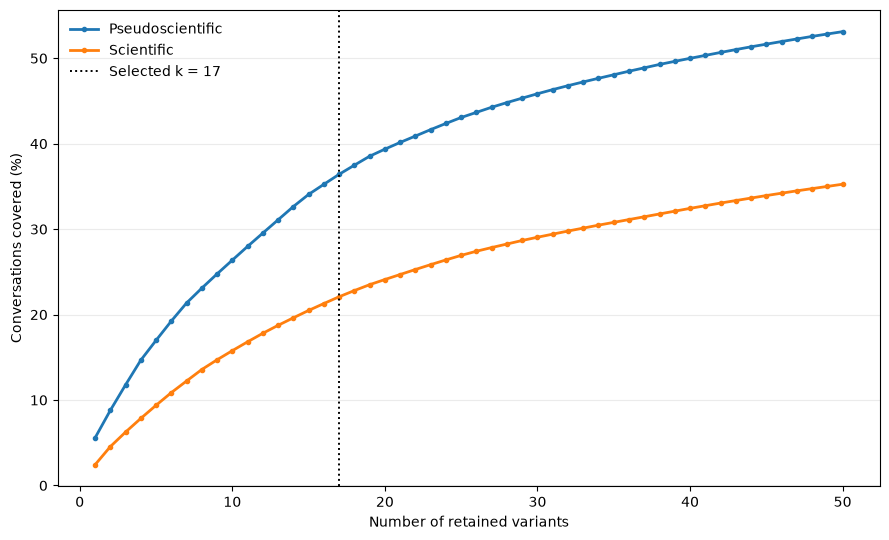

,audience,top_k_variants,conversations_covered,pct_conversations_covered
0,Pseudoscientific,1,630,5.556536
1,Pseudoscientific,2,995,8.775798
2,Pseudoscientific,3,1334,11.765744
3,Pseudoscientific,4,1662,14.658670
4,Pseudoscientific,5,1925,16.978303
...,...,...,...,...
95,Scientific,46,1984,34.206897
96,Scientific,47,2000,34.482759
97,Scientific,48,2015,34.741379
98,Scientific,49,2030,35.000000


In [27]:
import matplotlib.pyplot as plt

max_top_k = 50
selected_top_k = 17
coverage_rows = []

datasets = {
    'Pseudoscientific': pseudoscientific_df,
    'Scientific': scientific_df,
}

for audience, df in datasets.items():
    tmp = df.dropna(
        subset=['conversation_id', 'timestamp', 'etiqueta', 'emotion']
    ).copy()

    tmp['activity'] = (
        tmp['etiqueta'].astype(str).str.strip()
        + ' - '
        + tmp['emotion'].astype(str).str.strip()
    )
    tmp = tmp.sort_values(['conversation_id', 'timestamp'])

    variant_counts = (
        tmp.groupby('conversation_id')['activity']
        .agg(tuple)
        .value_counts()
    )

    total_conversations = int(variant_counts.sum())
    cumulative_conversations = variant_counts.head(max_top_k).cumsum()

    for top_k, conversations in enumerate(cumulative_conversations, start=1):
        coverage_rows.append({
            'audience': audience,
            'top_k_variants': top_k,
            'conversations_covered': int(conversations),
            'pct_conversations_covered': (
                100 * conversations / total_conversations
            ),
        })

coverage_df = pd.DataFrame(coverage_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))

for audience, audience_df in coverage_df.groupby('audience'):
    ax.plot(
        audience_df['top_k_variants'],
        audience_df['pct_conversations_covered'],
        marker='o',
        markersize=3,
        linewidth=2,
        label=audience,
    )

ax.set_xlabel('Number of retained variants')
ax.set_ylabel('Conversations covered (%)')
#ax.set_title('Cumulative conversation coverage by number of retained process variants')

ax.axvline(
    selected_top_k,
    color='black',
    linestyle=':',
    linewidth=1.4,
    label=f'Selected k = {selected_top_k}',
)

ax.grid(True, axis='y', alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()

# Export the image before displaying it.
fig.savefig(
    'Data/Results/Submission_Figures/cumulative_conversation_coverage.png',
    dpi=300,
    bbox_inches='tight',
)

plt.show()

coverage_df

**Exact long-tail variant summary**


In [28]:
long_tail_rows = []

for audience, df in datasets.items():
    tmp = df.dropna(subset=['conversation_id', 'timestamp', 'etiqueta', 'emotion']).copy()
    tmp['activity'] = tmp['etiqueta'].astype(str).str.strip() + ' - ' + tmp['emotion'].astype(str).str.strip()
    tmp = tmp.sort_values(['conversation_id', 'timestamp'])

    variant_counts = tmp.groupby('conversation_id')['activity'].agg(tuple).value_counts()
    total_conversations = int(variant_counts.sum())
    total_variants = int(len(variant_counts))

    repeated_variant_counts = variant_counts[variant_counts > 1]
    singleton_variant_counts = variant_counts[variant_counts == 1]

    long_tail_rows.append({
        'Audience': audience,
        'Total conversations': total_conversations,
        'Total variants': total_variants,
        'Variants occurring once': int(len(singleton_variant_counts)),
        'Variants occurring once (%)': round(100 * len(singleton_variant_counts) / total_variants, 2),
        'Variants occurring more than once': int(len(repeated_variant_counts)),
        'Variants occurring more than once (%)': round(100 * len(repeated_variant_counts) / total_variants, 2),
        'Conversations in repeated variants': int(repeated_variant_counts.sum()),
        'Conversations in repeated variants (%)': round(100 * repeated_variant_counts.sum() / total_conversations, 2),
        'Conversations in singleton variants': int(singleton_variant_counts.sum()),
        'Conversations in singleton variants (%)': round(100 * singleton_variant_counts.sum() / total_conversations, 2),
    })

variant_long_tail_summary_df = pd.DataFrame(long_tail_rows)
variant_long_tail_summary_df


,Audience,Total conversations,Total variants,Variants occurring once,Variants occurring once (%),Variants occurring more than once,Variants occurring more than once (%),Conversations in repeated variants,Conversations in repeated variants (%),Conversations in singleton variants,Conversations in singleton variants (%)
0,Pseudoscientific,11338,3019,2322,76.91,697,23.09,9016,79.52,2322,20.48
1,Scientific,5800,2505,2048,81.76,457,18.24,3752,64.69,2048,35.31


**Select dataset**

In the following chunk only one line of the first 2 lines should be uncommented. Here the user selects the dataset that wants to analyze and then executes the process mining analysis for that dataset.

In [29]:
#selected_df = scientific_df.copy()
selected_df = pseudoscientific_df.copy()

if selected_df.equals(pseudoscientific_df):
    selected_audience = "pseudoscientific"
elif selected_df.equals(scientific_df):
    selected_audience = "scientific"
else:
    selected_audience = "selected_dataset"

# Rename thematic label for analysis/visualization
selected_df["etiqueta"] = selected_df["etiqueta"].replace({
    "Expression of personal feelings": "Expression of feelings"
})

print(f"Selected dataset: {selected_audience}")

Selected dataset: scientific


**Selected dataset analysis**

In [30]:
selected_df['language'].value_counts()

language
es                11963
en                 4561
pt                 2104
hi                  446
it                  443
sw                  307
ur                  264
el                  102
de                   46
tr                   44
bg                   35
nl                   23
ru                   14
pl                   10
th                   10
fr                    5
unclassifiable        3
zh                    3
ja                    2
ar                    1
Name: count, dtype: int64

In [31]:
selected_df['etiqueta'].value_counts()

etiqueta
Expression of feelings                   7474
Comparison                               5759
Compliment                               1612
Advice request                            982
Medical treatment                         969
Emoji-only or \nBrief Acknowledgement     786
Thanking                                  660
Speculation                               400
Greetings                                 321
Advice Give                               226
Criticism                                 214
Pseudoscientific treatment                177
Anecdote                                  175
Joke                                      158
Unclassifiable                             92
Opinion                                    87
Tribute                                    73
Plans                                      61
Information Exchange                       52
Spam                                       32
Opinion Request                            30
Event anticipation       

In [32]:
selected_df['emotion'].value_counts()

emotion
Negative    9008
Positive    8735
Neutral     2643
Name: count, dtype: int64

**Process mining**

In [33]:
from pm4py.objects.log.util import dataframe_utils
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
# Step 1: Rename columns for PM4Py
selected_df['activity'] = selected_df['etiqueta'] + " - " + selected_df['emotion']
event_log = selected_df.rename(columns={
    'conversation_id': 'case:concept:name',
    'timestamp': 'time:timestamp',
    'activity': 'concept:name',

})


# Step 2: Convert to event-log format
log = log_converter.apply(event_log)

In [34]:
len(event_log['case:concept:name'].unique())

5800

In [35]:
from pathlib import Path

from pathlib import Path

import pm4py
variants = pm4py.get_variants_as_tuples(log)
len(variants)

2505

In [36]:
# Get variants as a dictionary
variants = pm4py.get_variants_as_tuples(log)

# Convert to a DataFrame and count how many times each variant appears
variants_df = pd.DataFrame({'Variants': list(variants.keys()), 'Repetitions': [len(v) for v in variants.values()]})

# Keep the most frequent variants
common_variants = variants_df.sort_values(by='Repetitions', ascending=False).head(35)
pd.set_option('display.max_colwidth', None)

# Display the common variants
print(common_variants['Variants'])


12                    (Expression of feelings - Positive, Expression of feelings - Positive)
16                                            (Comparison - Negative, Comparison - Negative)
80                    (Expression of feelings - Negative, Expression of feelings - Negative)
133                   (Expression of feelings - Negative, Expression of feelings - Positive)
47                                (Expression of feelings - Negative, Comparison - Negative)
182                                           (Compliment - Positive, Compliment - Positive)
360                (Compliment - Positive, Emoji-only or \nBrief Acknowledgement - Positive)
160                               (Compliment - Positive, Expression of feelings - Positive)
6                      (Expression of feelings - Negative, Expression of feelings - Neutral)
163                                             (Compliment - Positive, Thanking - Positive)
243                               (Expression of feelings - Negative, 

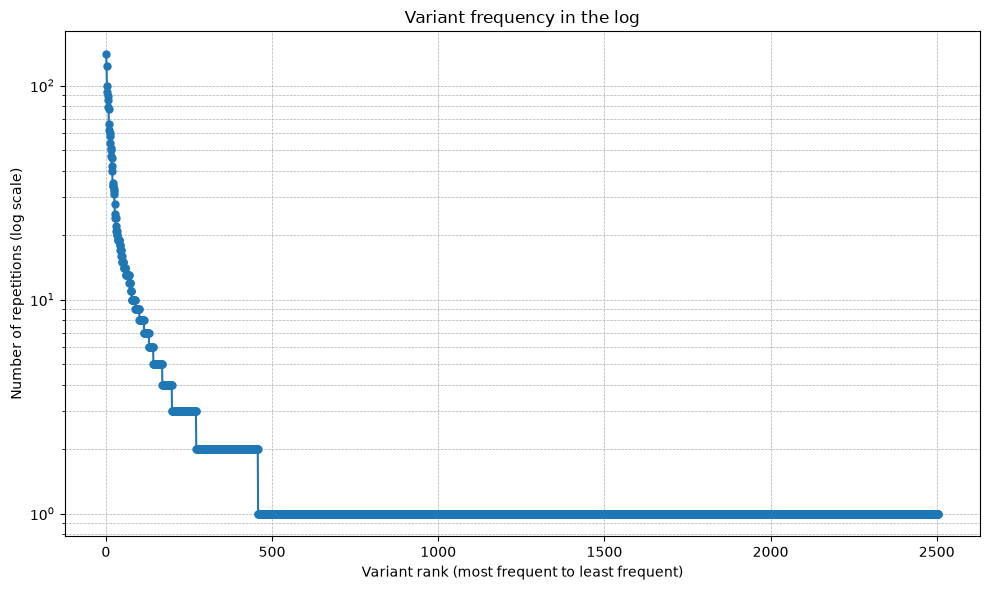

In [37]:
import matplotlib.pyplot as plt

# Sort by number of repetitions from highest to lowest
variants_df = variants_df.sort_values(by='Repetitions', ascending=False).reset_index(drop=True)

# Create a point plot with only the y-axis on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.plot(variants_df.index + 1, variants_df['Repetitions'], 'o-', markersize=5)
plt.yscale('log')
plt.xlabel('Variant rank (most frequent to least frequent)')
plt.ylabel('Number of repetitions (log scale)')
plt.title('Variant frequency in the log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [38]:
from PIL import Image

# Keep only the top 17 variants
top_17_variants = pm4py.filter_variants_top_k(log, 17)

# Discover the heuristics net
heuristics_map = pm4py.discover_heuristics_net(top_17_variants)

# Define visualization parameters
parameters = {"fontsize": 75}

# Generate the visualization
gviz = pm4py.visualization.heuristics_net.visualizer.apply(
    heuristics_map,
    parameters=parameters
)

# Define output directory
process_graph_dir = Path("Data/Results/Process_Mining/Final")
process_graph_dir.mkdir(parents=True, exist_ok=True)

# Define output file
process_graph_file = (
    process_graph_dir
    / f"{selected_audience}_heuristics_net_top_17.png"
)

# Save the original visualization
pm4py.visualization.heuristics_net.visualizer.save(
    gviz,
    str(process_graph_file)
)

# Limit the image dimensions to a maximum of 1200 x 1200 pixels
MAX_SIZE = 1200

with Image.open(process_graph_file) as img:
    img.thumbnail(
        (MAX_SIZE, MAX_SIZE),
        Image.Resampling.LANCZOS
    )
    img.save(process_graph_file)

print(f"Process graph saved to: {process_graph_file}")

# Display the resized image
Image.open(process_graph_file).show()

Process graph saved to: Data\Results\Process_Mining\Final\scientific_heuristics_net_top_17.png


In [40]:
from pm4py.convert import convert_to_petri_net
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator

top_500_variants = pm4py.filter_variants_top_k(log, 500)

# Convert the Heuristics Net to a Petri Net
net, initial_marking, final_marking = convert_to_petri_net(heuristics_map)

# Calculate fitness using alignment-based replay
fitness_result = replay_fitness_evaluator.apply(
    top_500_variants, 
    net, 
    initial_marking, 
    final_marking, 
    variant=replay_fitness_evaluator.Variants.ALIGNMENT_BASED
)

# Display results
print("Fitness:")
for key, value in fitness_result.items():
    print(f"{key}: {value:.4f}")

C:\Users\stefa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
aligning log, completed variants :: 100%|██████████| 500/500 [00:01<00:00, 308.10it/s]

Fitness:
percFitTraces: 21.8445
averageFitness: 0.6431
percentage_of_fitting_traces: 21.8445
average_trace_fitness: 0.6431
log_fitness: 0.6431
